# Week 6 Lab: Compare LLM families, decode, and query a model

**Module:** Generative AI (MSc in Artificial Intelligence) · **Time:** 2 hours · **Learning outcomes:** MIMLO 1, 3, 5

1. Compare **tokenisers** across model families.
2. Give the same inputs to **BERT** (encoder), **Flan-T5** (encoder–decoder) and **Qwen** (decoder LLM).
3. Implement **top-k** and **top-p** sampling and compare decoding strategies.
4. Measure **perplexity**.
5. Query a hosted LLM through an **API** (optional free key) and log tokens and latency.
6. Try a small **reasoning model** with thinking on and off.

We use openly licensed models (Apache 2.0). Llama models are also open-weight but gated: you must accept Meta's licence on Hugging Face before downloading them.

> **INSTRUCTOR VERSION — contains solutions. Do not distribute before the lab.**

> **How to run this notebook**
> - **Google Colab (recommended):** File ▸ Upload notebook, then Runtime ▸ Change runtime type ▸ **T4 GPU**. Run cells top to bottom with Shift+Enter.
> - **Local Jupyter / VS Code:** Python 3.10+; run the install cell once. A GPU is optional: every cell has a CPU-friendly setting.
> - **API keys (optional cells only):** store keys in Colab ▸ 🔑 Secrets or an environment variable. Never paste a key into a notebook you share.
> - Cells marked **TODO** are yours to complete. Questions marked ✍️ need a short written answer.

## Start here: what a chat request actually does

A user question becomes a role-labelled message. The model's chat template
adds the formatting it expects, the tokenizer creates IDs, and the decoder
predicts successive answer tokens. The helper removes the original input
tokens before decoding the answer. These calls use already learned weights;
generating an answer is different from training a model.

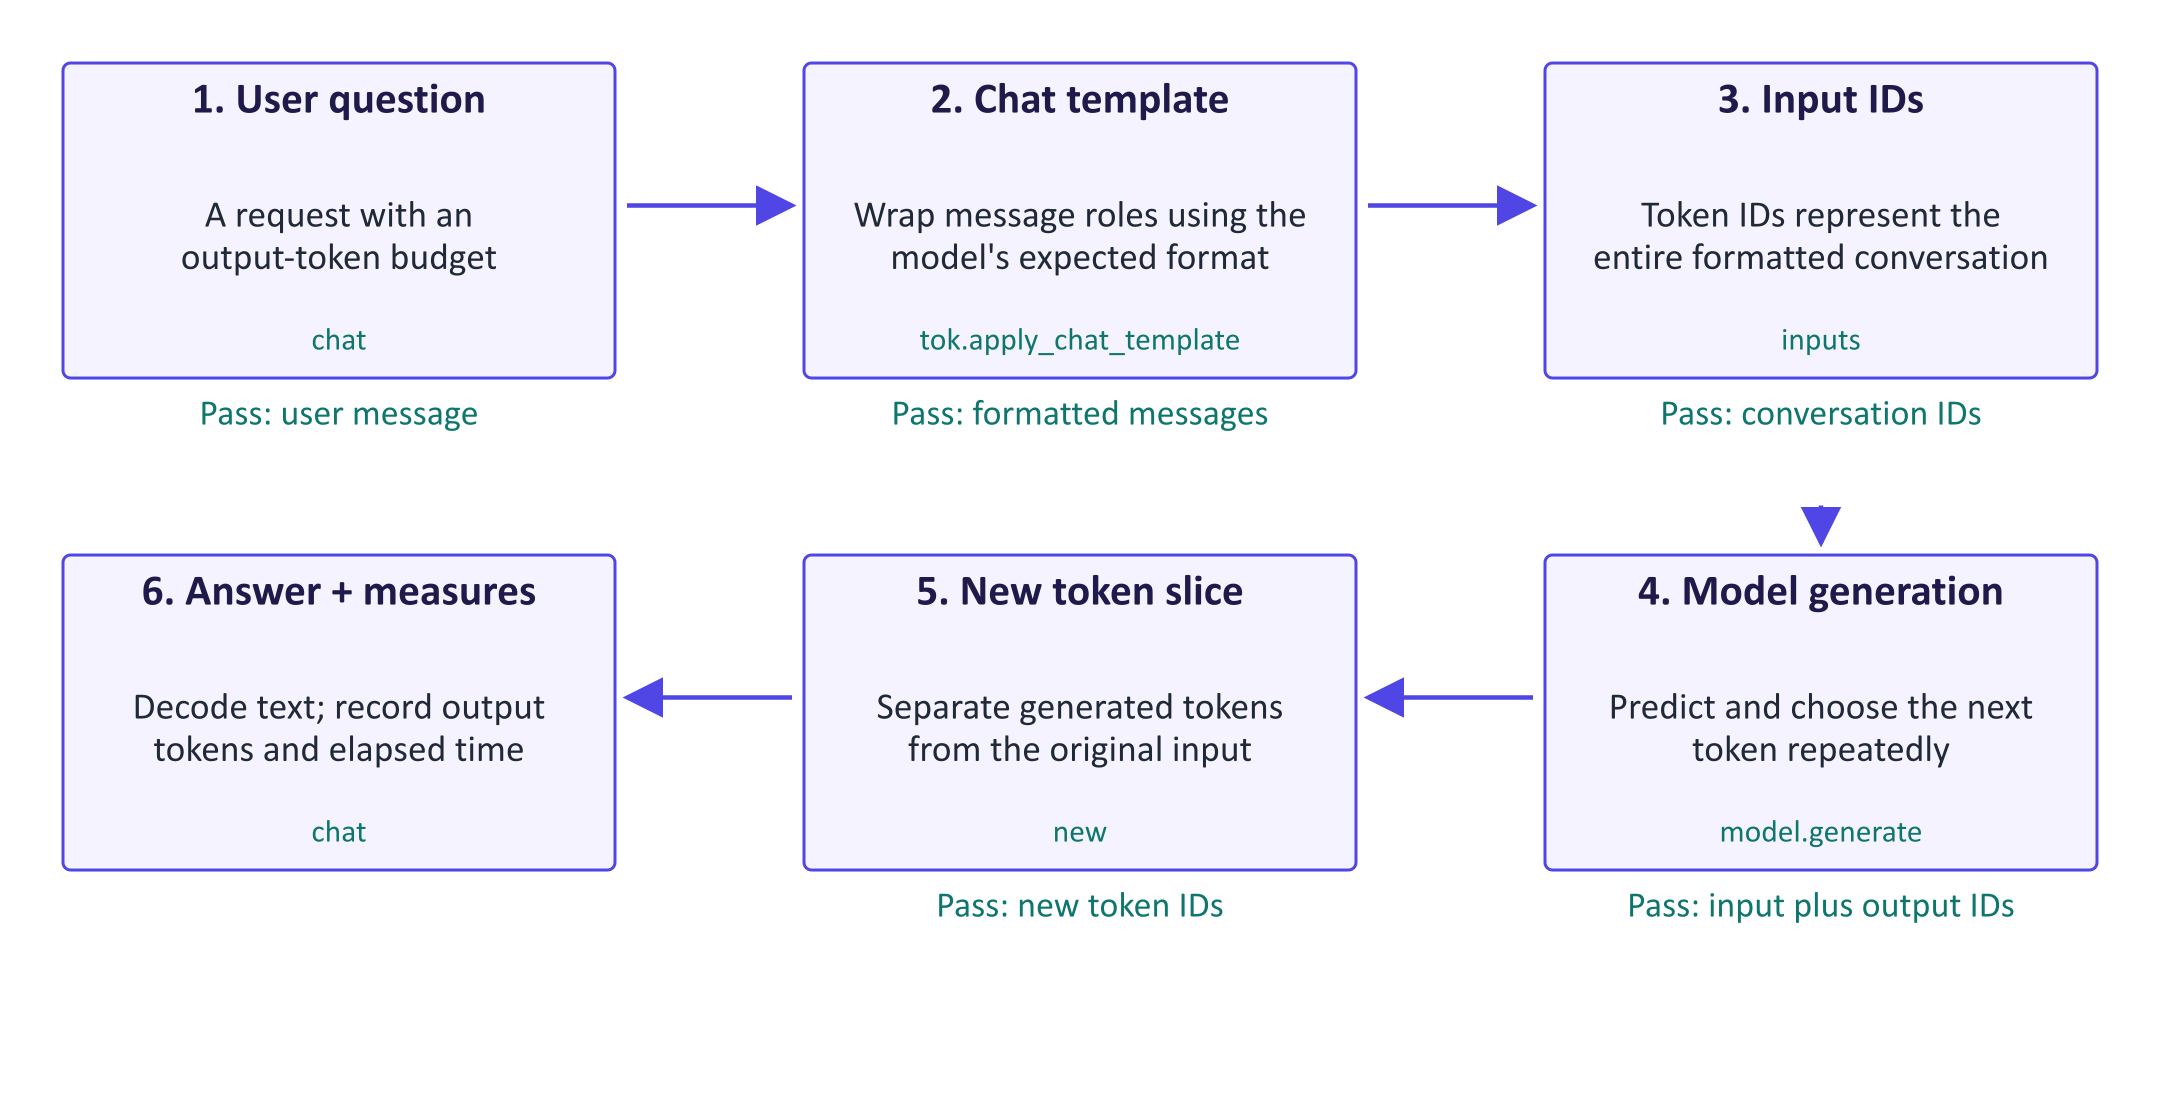

## Your map from experiments to code

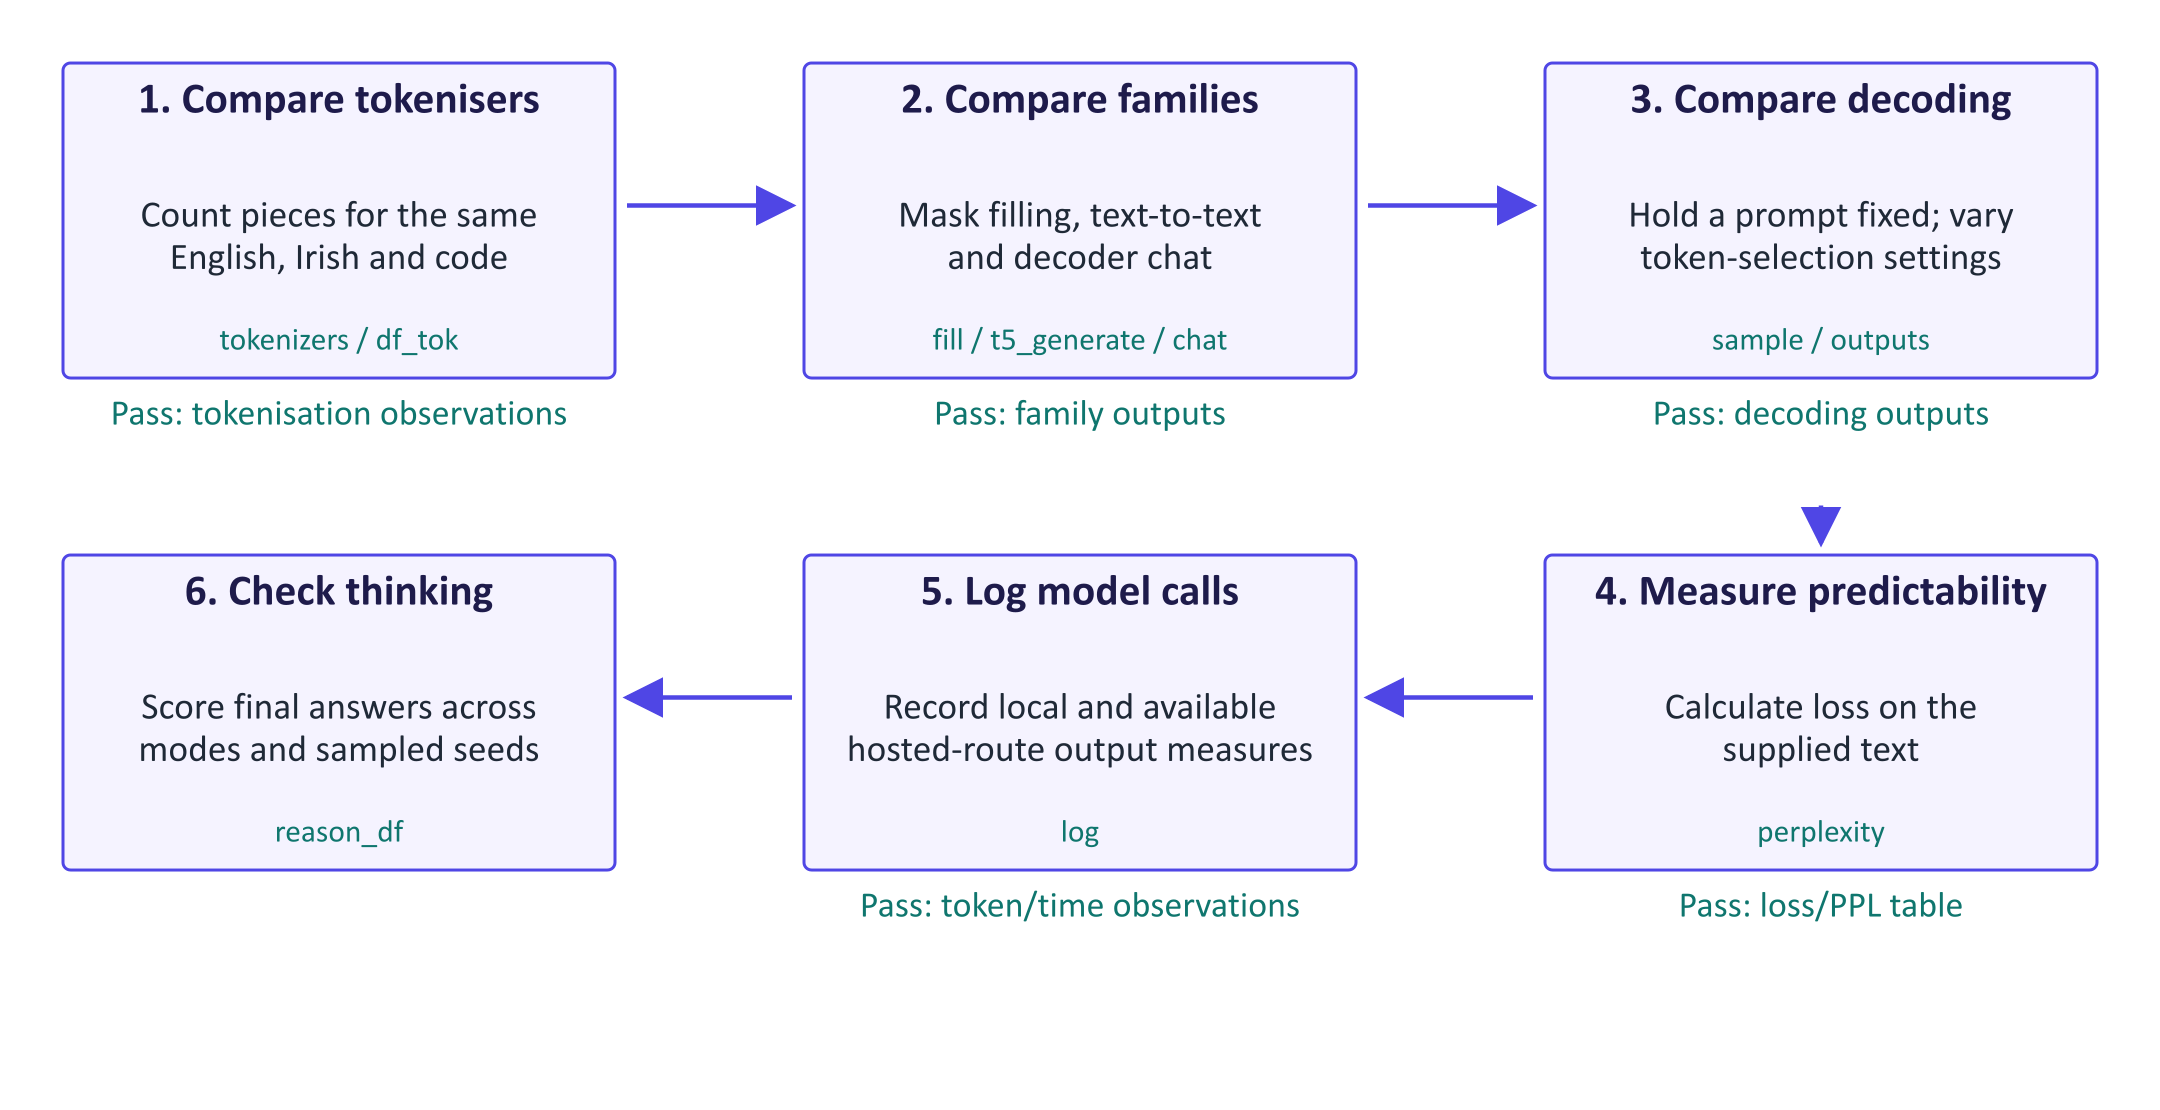

| Experiment | Find this code | Observe this |
|---|---|---|
| Token counts | `tokenizers`, `df_tok` | Different pieces for the same source text |
| Three families | `fill`, `t5_generate`, `chat` | Mask filling, text-to-text and conversation |
| Decoding | `sample`, `outputs` | The same prefix under different token-selection rules |
| Predictability | `perplexity` | Loss within each tokenizer/model pair |
| Call logging | `log` | Generated-token counts and elapsed time |
| Thinking comparison | `reason_df` | Finished answers, correctness, tokens and time together |

These are separate comparison experiments. Read each table's definition
before deciding that one result is better. Per-token perplexity from two
different tokenizers is not a direct ranking of answer quality.

In [ ]:
%pip install -q transformers accelerate huggingface_hub pandas

In [ ]:
import math
import os
import random
import re
import time

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoModelForSeq2SeqLM, AutoTokenizer, pipeline

SMOKE = os.environ.get("GENAI_LAB_SMOKE") == "1"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
pd.set_option("display.max_colwidth", 120)
DECODER_ID = "Qwen/Qwen2.5-0.5B-Instruct"
T5_ID = "google/flan-t5-small" if SMOKE else "google/flan-t5-base"
print("device:", DEVICE)

## Part 1 · Tokenisers differ between families

**TODO 1:** for each tokenizer and text, compute the number of tokens and the **tokens per word** (split the text on whitespace to count words).

In [ ]:
texts = {
    "English": "Large language models predict the next token. Tokenisers split text into pieces.",
    "Irish": "Tuarann samhlacha móra teanga an chéad chomhartha eile. Roinneann tokenizers téacs ina phíosaí.",
    "Code": "def softmax(z):\n    e = np.exp(z - z.max())\n    return e / e.sum()",
}
tokenizers = {"GPT-2": "gpt2", "BERT": "bert-base-uncased", "Flan-T5": T5_ID, "Qwen2.5": DECODER_ID}
rows = []
for name, mid in tokenizers.items():
    tok = AutoTokenizer.from_pretrained(mid)
    for tname, text in texts.items():
        n_tokens = len(tok(text, add_special_tokens=False)["input_ids"])
        per_word = n_tokens / len(text.split())
        rows.append({"tokenizer": name, "vocab": len(tok), "text": tname, "tokens": n_tokens, "tokens/word": round(per_word, 2)})
df_tok = pd.DataFrame(rows).pivot(index="tokenizer", columns="text", values="tokens/word")
df_tok

In [ ]:
tok = AutoTokenizer.from_pretrained(DECODER_ID)
for w in ["unbelievable", "Dublin", "Dún Laoghaire", "ChatGPT", "   indentation"]:
    print(f"{w!r:18} -> {tok.tokenize(w)}")

## Part 2 · Three families, same inputs

### 2.1 BERT (encoder): fill in the blank

In [ ]:
fill = pipeline("fill-mask", model="bert-base-uncased", device=0 if DEVICE == "cuda" else -1)
for s in ["The capital of Ireland is [MASK].", "Generative models can [MASK] new images.", "The doctor said [MASK] would call back later."]:
    print(s, "->", [(r["token_str"], round(r["score"], 2)) for r in fill(s)[:4]])

### 2.2 Flan-T5 (encoder–decoder): everything is text-to-text

In [ ]:
t5_tok = AutoTokenizer.from_pretrained(T5_ID)
t5 = AutoModelForSeq2SeqLM.from_pretrained(T5_ID).to(DEVICE).eval()


def t5_generate(prompt, max_new_tokens=40):
    ids = t5_tok(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        out = t5.generate(**ids, max_new_tokens=max_new_tokens)
    return t5_tok.decode(out[0], skip_special_tokens=True)


TASKS = {
    "QA": "What is the capital of Ireland?",
    "Translate": "Translate English to German: How old are you?",
    "Summarise": "Summarize in one sentence: Generative models learn a probability distribution over data and can sample new examples that look like the training data. They include VAEs, GANs, diffusion models and large language models.",
    "Sentiment": "Is this review positive or negative? 'The lab was confusing and the code kept crashing.'",
}
for k, v in TASKS.items():
    print(f"{k:10s} -> {t5_generate(v)}")

### 2.3 A decoder LLM (Qwen2.5-0.5B-Instruct): chat

In [ ]:
dec_tok = AutoTokenizer.from_pretrained(DECODER_ID)
dec = AutoModelForCausalLM.from_pretrained(DECODER_ID).to(DEVICE).eval()


def chat(model, tok, question, max_new_tokens=80, sampling=None, **template_kw):
    """Greedy decoding unless `sampling` gives generate() settings such as dict(do_sample=True, temperature=0.7)."""
    msgs = [{"role": "user", "content": question}]
    # Roles need the model-specific template before they become input token IDs.
    inputs = tok.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt", return_dict=True, **template_kw).to(DEVICE)
    t0 = time.time()
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=16 if SMOKE else max_new_tokens, pad_token_id=tok.eos_token_id,
                             **(sampling or {"do_sample": False}))
    # Decoder output contains the input prefix first, then the newly generated IDs.
    new = out[0, inputs["input_ids"].shape[1]:]
    return tok.decode(new, skip_special_tokens=True).strip(), len(new), time.time() - t0


results = []
for k, v in TASKS.items():
    ans, n, sec = chat(dec, dec_tok, v)
    results.append({"task": k, "Flan-T5": t5_generate(v), "Qwen2.5-0.5B": ans})
pd.DataFrame(results)

✍️ **Question 1.** Compare the three families. Which tasks did each handle well, and why can BERT not answer the QA or translation tasks directly? When would you still choose BERT or T5 over a decoder LLM?

**✅ Model answer:**
BERT only predicts masked tokens (or produces embeddings); it ranks words for a blank, e.g. "dublin" for the capital, but it cannot generate a free-text answer or translation because it has no decoder generating left to right. Flan-T5 handles short, well-specified text-to-text tasks (QA, translation, one-sentence summaries, sentiment) concisely, since it was instruction-tuned on many such tasks. The decoder LLM gives more fluent, longer answers and follows open instructions, but a 0.5B model can be verbose or make errors. BERT-style encoders remain the best choice for classification, tagging and embeddings for search (cheap, fast, accurate after fine-tuning); T5 for efficient input→output tasks such as summarisation or translation at scale; decoder LLMs for open-ended generation, chat, code and agents. Also note the gender bias in the "doctor said [MASK]" example: BERT often predicts "he".

## Part 3 · Decoding strategies

**TODO 2:** implement `top_k_filter(logits, k)`: keep the k largest logits, set the rest to −∞.

**TODO 3:** implement `top_p_filter(logits, p)`: sort probabilities in descending order, keep the smallest set whose cumulative probability ≥ p (always keep the top token), set the rest to −∞.

**Keep prediction and choice separate.** A logit is a model score. A filter
excludes some candidates; softmax turns the retained scores into probabilities.
Greedy decoding and sampling then use those probabilities differently.
Top-k's score threshold can retain more than k candidates when scores tie.

In [ ]:
def top_k_filter(logits, k):
    kth = torch.topk(logits, k).values[..., -1, None]
    return logits.masked_fill(logits < kth, float("-inf"))


def top_p_filter(logits, p):
    sorted_logits, idx = torch.sort(logits, descending=True)
    cum = sorted_logits.softmax(-1).cumsum(-1)
    remove = cum - sorted_logits.softmax(-1) >= p  # tokens after the nucleus is complete
    sorted_logits = sorted_logits.masked_fill(remove, float("-inf"))
    return torch.full_like(logits, float("-inf")).scatter(-1, idx, sorted_logits)


test = torch.tensor([2.0, 1.0, 0.5, 0.1, -1.0])
assert torch.isinf(top_k_filter(test, 2)).sum() == 3
kept = (~torch.isinf(top_p_filter(test, 0.8))).sum().item()
print("top-p 0.8 keeps", kept, "tokens:", test.softmax(-1).numpy().round(3))
assert kept == 3, "probabilities are [0.56, 0.21, 0.12, …]: the first three reach ≥ 0.8"
print("✅ filters correct")


@torch.no_grad()
def sample(prompt, n_new=40, temperature=1.0, k=None, p=None, seed=0):
    torch.manual_seed(seed)
    ids = dec_tok(prompt, return_tensors="pt")["input_ids"].to(DEVICE)
    # This demonstration runs a fixed number of steps; it has no explicit EOS stop.
    for _ in range(8 if SMOKE else n_new):
        # The final prefix position supplies scores for the next token only.
        logits = dec(ids).logits[0, -1] / temperature
        if k:
            logits = top_k_filter(logits, k)
        if p:
            logits = top_p_filter(logits, p)
        nxt = torch.multinomial(logits.softmax(-1), 1)
        ids = torch.cat([ids, nxt[None]], dim=1)
    return dec_tok.decode(ids[0], skip_special_tokens=True)


prompt = "Once upon a time in a small village by the sea,"
ids = dec_tok(prompt, return_tensors="pt").to(DEVICE)
with torch.no_grad():
    greedy = dec_tok.decode(dec.generate(**ids, max_new_tokens=8 if SMOKE else 40, do_sample=False, pad_token_id=dec_tok.eos_token_id)[0], skip_special_tokens=True)
    beam = dec_tok.decode(dec.generate(**ids, max_new_tokens=8 if SMOKE else 40, num_beams=4, do_sample=False, pad_token_id=dec_tok.eos_token_id)[0], skip_special_tokens=True)
outputs = {"greedy": greedy, "beam (4)": beam,
           "T=1.0, top-k 50": sample(prompt, k=50), "T=0.7, top-p 0.9": sample(prompt, temperature=0.7, p=0.9),
           "T=1.5 (no filter)": sample(prompt, temperature=1.5)}
for k_, v in outputs.items():
    print(f"--- {k_}\n{v}\n")


def distinct_2(text):
    toks = text.split()
    bigrams = list(zip(toks, toks[1:]))
    return len(set(bigrams)) / max(1, len(bigrams))


print({k_: round(distinct_2(v), 2) for k_, v in outputs.items()})

✍️ **Question 2.** Compare the outputs and their distinct-2 scores (share of unique word pairs). Which strategy would you use for (a) a story generator, (b) extracting a date from an email, (c) machine translation with an encoder–decoder?

**✅ Model answer:**
Greedy and beam outputs are deterministic and tend to be repetitive or generic (lower distinct-2); sampling with top-p/top-k gives more varied text, and T = 1.5 without filtering often becomes incoherent (high diversity but low quality). (a) Story generator: temperature ≈ 0.7–1.0 with top-p ≈ 0.9 for variety without nonsense. (b) Extracting a date: greedy (temperature 0) plus format validation, since there is one right answer. (c) Translation with an encoder–decoder: beam search (e.g. 4–5 beams) is the traditional best choice because it finds a high-probability complete sequence. Always report the settings.

## Part 4 · Perplexity

**TODO 4:** a causal LM returns the mean negative log-likelihood per token as `.loss` when you pass `labels=input_ids`. Convert it to perplexity.

In [ ]:
gpt2_tok = AutoTokenizer.from_pretrained("gpt2")
gpt2 = AutoModelForCausalLM.from_pretrained("gpt2").to(DEVICE).eval()


@torch.no_grad()
def perplexity(model, tok, text):
    ids = tok(text, return_tensors="pt").to(DEVICE)
    # The causal-LM implementation shifts labels internally to score next tokens.
    loss = model(**ids, labels=ids["input_ids"]).loss.item()
    return math.exp(loss)


s = "The students trained a small language model and measured its perplexity on held-out text."
w = s.split(); random.seed(0)
samples = {"normal": s, "shuffled words": " ".join(random.sample(w, len(w))), "Irish": texts["Irish"], "code": texts["Code"]}
pd.DataFrame([{"text": k, "GPT-2 PPL": round(perplexity(gpt2, gpt2_tok, v), 1), "Qwen2.5 PPL": round(perplexity(dec, dec_tok, v), 1)} for k, v in samples.items()])

✍️ **Question 3.** Explain the pattern. Why can you not conclude from this table that one model is "better" than the other?

**✅ Model answer:**
Code has the lowest perplexity for both models (its syntax is very predictable; extremely low for Qwen, which saw a lot of code), then normal English; shuffling the same words raises perplexity sharply because word order carries most of the predictability; Irish is much higher for GPT-2 (trained mostly on English web text) than for the multilingual Qwen. (Instructor run, GPT-2 / Qwen: code 51 / 4, normal 312 / 127, Irish 1,443 / 710, shuffled 2,635 / 2,954.) The two models use different tokenisers (different vocabularies and token boundaries), so their per-token perplexities measure different prediction tasks and are not directly comparable; one would need the same tokeniser or a per-character/per-byte measure (bits per byte). Also, perplexity on four sentences is not a benchmark, and low perplexity says nothing about helpfulness, truthfulness or safety.

## Part 5 · Query a hosted LLM through an API (optional key)

Two free options (create keys with your own account and store them as Colab 🔑 Secrets):

* **Hugging Face Inference Providers:** `HF_TOKEN` from huggingface.co/settings/tokens (free monthly credits).
* **Google Gemini API:** `GEMINI_API_KEY` from Google AI Studio (free tier).

Without a key, the cell falls back to the local Qwen model so you can still complete the table.

In [ ]:
def get_secret(name):
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return os.environ.get(name)


question = "In two sentences, what is the difference between an encoder-only and a decoder-only transformer?"
log = []
hf_token = None if SMOKE else get_secret("HF_TOKEN")
if hf_token:
    from huggingface_hub import InferenceClient
    client = InferenceClient(api_key=hf_token)
    t0 = time.time()
    resp = client.chat.completions.create(model="Qwen/Qwen2.5-7B-Instruct", messages=[{"role": "user", "content": question}], max_tokens=120, temperature=0.2)
    log.append({"route": "HF Inference Providers", "model": "Qwen2.5-7B-Instruct", "seconds": round(time.time() - t0, 2),
                "prompt_tokens": resp.usage.prompt_tokens, "completion_tokens": resp.usage.completion_tokens, "answer": resp.choices[0].message.content})
gem_key = None if SMOKE else get_secret("GEMINI_API_KEY")
if gem_key:
    try:
        from google import genai
    except ImportError:
        import subprocess, sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "google-genai"])
        from google import genai
    g = genai.Client(api_key=gem_key)
    t0 = time.time()
    r = g.models.generate_content(model="gemini-flash-latest", contents=question)
    log.append({"route": "Gemini API", "model": "gemini-flash-latest", "seconds": round(time.time() - t0, 2),
                "prompt_tokens": r.usage_metadata.prompt_token_count, "completion_tokens": r.usage_metadata.candidates_token_count, "answer": r.text})
ans, n, sec = chat(dec, dec_tok, question, max_new_tokens=120)
log.append({"route": "local Transformers", "model": "Qwen2.5-0.5B-Instruct", "seconds": round(sec, 2), "prompt_tokens": None, "completion_tokens": n, "answer": ans})
pd.DataFrame(log)

## Part 6 · A small reasoning model: thinking on vs off

Qwen3 models have a switchable "thinking" mode. We ask two questions: an easy word problem (answer **21**) and a scheduling puzzle with a subtle constraint (answer **20** hours).

The model card recommends **sampling** in thinking mode (temperature 0.6, top-p 0.95, top-k 20): with greedy decoding the model can repeat itself until the token budget runs out. Sampled answers vary, so we run each question **three times** per mode and count correct answers. This part takes about 5–10 minutes on a T4.

The modes below also use different sampling parameters and token budgets.
Interpret the result as a comparison of those complete settings, rather than
an isolated experiment on the thinking switch. Score the final answer against
the known answer, and inspect whether the response actually finished.

In [ ]:
R_ID = "Qwen/Qwen3-0.6B"
r_tok = AutoTokenizer.from_pretrained(R_ID)
r_model = AutoModelForCausalLM.from_pretrained(R_ID).to(DEVICE).eval()
SAMPLING = {True: dict(do_sample=True, temperature=0.6, top_p=0.95, top_k=20),   # thinking mode (model card)
            False: dict(do_sample=True, temperature=0.7, top_p=0.8, top_k=20)}   # non-thinking mode (model card)
BUDGET = {True: 2048, False: 300}
PROBLEMS = {
    "word problem": ("Tom has 3 boxes with 4 apples each. He gives away 5 apples, then buys twice as many apples as he has left. "
                     "How many apples does he have now? Answer with a number.", 21),
    "scheduling puzzle": ("A lab has 3 GPUs. Each training run needs 2 GPUs for 4 hours. How many hours are needed to finish 5 runs "
                          "if runs can execute in parallel whenever GPUs are free? Answer with a number.", 20),
}
rows = []
for name, (question, gold) in PROBLEMS.items():
    for think in (False, True):
        for seed in range(1 if SMOKE else 3):
            torch.manual_seed(seed)
            ans, n, sec = chat(r_model, r_tok, question, BUDGET[think], sampling=SAMPLING[think], enable_thinking=think)
            final = ans.split("</think>")[-1]  # the text after the reasoning block
            nums = re.findall(r"-?\d+(?:\.\d+)?", final.replace(",", ""))
            finished = n < BUDGET[think]
            rows.append({"problem": name, "thinking": think, "seed": seed, "tokens": n, "seconds": round(sec, 1), "finished": finished,
                         "answer": nums[-1] if (nums and finished) else None,
                         "correct": bool(nums) and finished and float(nums[-1]) == gold})
reason_df = pd.DataFrame(rows)
print(final[-300:])  # the last answer, to see what the model writes
reason_df.groupby(["problem", "thinking"]).agg(correct=("correct", "sum"), runs=("correct", "size"), finished=("finished", "sum"),
                                               mean_tokens=("tokens", "mean"), mean_seconds=("seconds", "mean")).round(1)

*Optional, if time allows on a T4:* set `R_ID = "Qwen/Qwen3-1.7B"`, re-run the cell and compare. Does a larger model use its thinking budget better?

✍️ **Question 4.** For each problem, what changed with thinking on (correct answers, tokens, time)? Why should you not treat the visible reasoning as a trustworthy explanation? When is a reasoning model worth its cost?

**✅ Model answer:**
On the easy word problem both modes are right, but thinking costs about five times the tokens and time (instructor run: 3/3 correct in both modes, ≈150 vs ≈780 tokens): cost without benefit. On the scheduling puzzle the key constraint is that only one 2-GPU run fits on 3 GPUs at a time, so 5 runs × 4 h = 20 h. Without thinking, the 0.6 B model usually calculates as if runs could share GPUs (13.3 h, 40 h) and is right only sometimes (1/3); with thinking it explored at length but ran out of the 2,048-token budget every time (0/3): a very small reasoning model can "overthink" without converging, so reasoning gains depend on a capable base model and a sufficient budget. The visible reasoning is generated text: it can contain errors, skip steps or not match how the answer was actually computed, so we score the final answer against ground truth rather than trusting the explanation. Reasoning models are worth it for hard multi-step maths, logic, planning and code when accuracy matters more than latency and cost; for simple lookups, extraction or chat they waste time and money.

## Model card worksheet

Fill in for **two** models you used today (read their pages on huggingface.co):

| | Model 1 | Model 2 |
|---|---|---|
| Family and architecture | | |
| Parameters, context length | | |
| Training data (as disclosed) | | |
| Licence and restrictions | | |
| Evaluations reported | | |
| Limitations you observed today | | |

**Before next week:** bring one prompt you use regularly with an AI tool; we will improve and evaluate it.